<a href="https://colab.research.google.com/github/SANGHATI23/neurofhir-qc/blob/main/20_NeuroFHIR_TRACE_Gate_Calibration_HeldOut_Validation_Ablations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# NeuroFHIR-TRACE — Notebook 20
## TRACE Gate Calibration, Frozen Held-Out Evaluation, Ablations, and Bootstrap Confidence Intervals

**Project:** NeuroFHIR-TRACE — Provenance-Aware Reliability Gating for Longitudinal Neuroimaging AI

### Scientific role of this notebook

Notebook 19A demonstrated the engineering pipeline.  
Notebook 19B established repeatability, longitudinal stability, and an independent instability-reference framework.

**Notebook 20 is the first formal TRACE evaluation notebook.**

It implements the predeclared sequence:

1. load the fixed subject split from Notebook 19B;
2. build TRACE component signals;
3. calibrate only on **development subjects**;
4. freeze the gate;
5. evaluate exactly once on **held-out subjects**;
6. compare component ablations against full TRACE;
7. report discrimination, calibration, review rate, false-change capture, and bootstrap confidence intervals.

### TRACE component models

- **V — Variability only**
- **D — Domain/site/scanner shift only**
- **P — Provenance only**
- **L — Longitudinal plausibility only**
- **FULL TRACE — V + D + P + L**

### Important scientific rule

The held-out labels must not be used to select thresholds, tune features, or modify the model after inspection.

If only the synthetic/demo fallback is available, all results are **pipeline-validation results only**, not manuscript evidence.


In [1]:

# ============================================================
# 0. COLAB SETUP
# ============================================================

!pip -q install pandas numpy scipy scikit-learn statsmodels pyarrow matplotlib

from pathlib import Path
import json, math, random, warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
    confusion_matrix
)

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

ROOT = Path("/content/neurofhir_trace")
IN19B = ROOT / "outputs_19B"
OUT_DIR = ROOT / "outputs_20"
FIG_DIR = OUT_DIR / "figures"

for p in [OUT_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

N_BOOT = 500

print("Input:", IN19B)
print("Output:", OUT_DIR)


Input: /content/neurofhir_trace/outputs_19B
Output: /content/neurofhir_trace/outputs_20



# 1. Load Notebook 19B artifacts

Preferred files:

```text
outputs_19B/
├── evidence_19B_normalized.parquet
├── independent_instability_reference.parquet
├── trace_subject_split.csv
├── independent_reference_thresholds.json
├── visit_level_technical_stability.csv
├── longitudinal_direction_concordance.csv
└── biological_vs_technical_change.csv
```

If these are unavailable, the notebook enters **DEMO_MODE** and creates a fully independent synthetic evaluation table so the calibration/evaluation code remains runnable.


In [2]:

# ============================================================
# 1. LOAD 19B ARTIFACTS
# ============================================================

paths = {
    "evidence": IN19B / "evidence_19B_normalized.parquet",
    "reference": IN19B / "independent_instability_reference.parquet",
    "split": IN19B / "trace_subject_split.csv",
    "visit_stability": IN19B / "visit_level_technical_stability.csv",
    "longitudinal": IN19B / "longitudinal_direction_concordance.csv",
    "bio_tech": IN19B / "biological_vs_technical_change.csv",
    "ref_thresholds": IN19B / "independent_reference_thresholds.json",
}

available = {k: p.exists() for k, p in paths.items()}
print(pd.Series(available, name="available"))

DEMO_MODE = not (
    available["evidence"] and
    available["reference"] and
    available["split"]
)

print("\nDEMO_MODE =", DEMO_MODE)


evidence           False
reference          False
split              False
visit_stability    False
longitudinal       False
bio_tech           False
ref_thresholds     False
Name: available, dtype: bool

DEMO_MODE = True



# 2. Build evaluation table

### Preferred real-data behavior

When 19B files are available, Notebook 20 builds one row per **subject × visit** with:

- `variability_risk`: patient/visit technical CV or replicate dispersion;
- `domain_risk`: site/scanner deviation estimated using development data only;
- `provenance_risk`: missing/incomplete provenance;
- `longitudinal_risk`: instability of change direction across technical conditions;
- `unstable_reference`: independent instability outcome from 19B.

### Independence hierarchy for the reference

The notebook prefers, in order:

1. externally supplied / known instability labels;
2. real test-retest disagreement;
3. 19B independent reference;
4. synthetic latent instability in DEMO_MODE.

If the 19B reference was itself partially derived from the same signal later used by TRACE, that must be disclosed as a limitation. For the final ICHI run, use the strongest available external/test-retest reference.


In [3]:

# ============================================================
# 2A. REAL/19B PATH
# ============================================================

if not DEMO_MODE:
    evidence = pd.read_parquet(paths["evidence"])
    condition_ref = pd.read_parquet(paths["reference"])
    split_df = pd.read_csv(paths["split"])

    if available["visit_stability"]:
        visit_stability = pd.read_csv(paths["visit_stability"])
    else:
        visit_stability = pd.DataFrame()

    if available["longitudinal"]:
        longitudinal = pd.read_csv(paths["longitudinal"])
    else:
        longitudinal = pd.DataFrame()

    if available["bio_tech"]:
        bio_tech = pd.read_csv(paths["bio_tech"])
    else:
        bio_tech = pd.DataFrame()

    evidence = evidence.merge(
        split_df[["subject_id","split"]],
        on="subject_id",
        how="left",
        suffixes=("","_splitfile")
    )

    if "split_splitfile" in evidence.columns:
        evidence["split"] = evidence["split"].fillna(
            evidence["split_splitfile"]
        )
        evidence = evidence.drop(columns=["split_splitfile"])

    print("Loaded real/19B artifacts.")
    print("Evidence rows:", len(evidence))
    print("Subjects:", evidence.subject_id.nunique())


In [4]:

# ============================================================
# 2B. DEMO FALLBACK
# Independent latent outcome -> observed TRACE signals.
# ============================================================

if DEMO_MODE:
    n_subjects = 160
    subjects = [f"D{i:03d}" for i in range(1, n_subjects+1)]

    rng = np.random.default_rng(SEED)

    # Fixed grouped split.
    rng.shuffle(subjects)
    n_dev = int(0.70*n_subjects)
    dev_ids = set(subjects[:n_dev])

    rows = []

    for sid in subjects:
        split = "development" if sid in dev_ids else "heldout"

        # Independent latent technical instability.
        latent_unstable = rng.binomial(1, 0.38)

        # Signals are noisy measurements of instability.
        variability = np.clip(
            rng.normal(0.035 + 0.055*latent_unstable, 0.025),
            0, 0.25
        )

        domain = np.clip(
            rng.normal(0.7 + 1.4*latent_unstable, 0.8),
            0, 5
        )

        provenance = np.clip(
            rng.beta(1.2 + 2.5*latent_unstable, 8),
            0, 1
        )

        direction_stability = np.clip(
            rng.normal(0.88 - 0.38*latent_unstable, 0.18),
            0, 1
        )

        longitudinal_risk = 1-direction_stability

        # Independent downstream "false-change" event for utility analysis.
        false_change = rng.binomial(
            1,
            np.clip(
                0.08 + 0.50*latent_unstable + 0.15*longitudinal_risk,
                0, 0.95
            )
        )

        rows.append({
            "subject_id": sid,
            "visit_id": "M12",
            "split": split,
            "variability_risk": variability,
            "domain_risk": domain,
            "provenance_risk": provenance,
            "longitudinal_risk": longitudinal_risk,
            "unstable_reference": latent_unstable,
            "false_change_event": false_change,
            "reference_source": "synthetic_latent_independent"
        })

    eval_df = pd.DataFrame(rows)

    print("Created independent synthetic evaluation table.")
    print(eval_df.groupby("split")["subject_id"].nunique())


Created independent synthetic evaluation table.
split
development    112
heldout         48
Name: subject_id, dtype: int64



# 3. Construct TRACE signals from Notebook 19B outputs

This section runs only when 19B artifacts exist.

The exact signal engineering is deliberately transparent and can later be replaced by stronger real-data definitions without changing the held-out evaluation framework.


In [5]:

# ============================================================
# 3. SIGNAL ENGINEERING FROM 19B
# ============================================================

if not DEMO_MODE:

    # ---------- Variability risk ----------
    if len(visit_stability):
        v = visit_stability[
            ["subject_id","visit_id","technical_cv"]
        ].copy()
        v["variability_risk"] = v["technical_cv"].fillna(0)
    else:
        tmp = (
            evidence.groupby(["subject_id","visit_id"], as_index=False)
            .agg(
                technical_mean=("biomarker_value","mean"),
                technical_sd=("biomarker_value","std")
            )
        )
        tmp["variability_risk"] = (
            tmp["technical_sd"] /
            tmp["technical_mean"].abs().replace(0,np.nan)
        ).fillna(0)
        v = tmp[["subject_id","visit_id","variability_risk"]]

    # ---------- Provenance risk ----------
    if "provenance_completeness" in evidence.columns:
        p = (
            evidence.groupby(["subject_id","visit_id"], as_index=False)
            .agg(
                provenance_completeness=("provenance_completeness","mean")
            )
        )
        p["provenance_risk"] = (
            1-p["provenance_completeness"].clip(0,1)
        )
    else:
        p = evidence[
            ["subject_id","visit_id"]
        ].drop_duplicates()
        p["provenance_risk"] = 0.0

    # ---------- Longitudinal risk ----------
    if len(longitudinal) and "direction_preserved" in longitudinal.columns:
        lsub = (
            longitudinal[
                longitudinal.get("condition", pd.Series(index=longitudinal.index, dtype=str)) != "clean"
            ]
            .groupby("subject_id", as_index=False)
            .agg(
                direction_stability=("direction_preserved","mean")
            )
        )
        lsub["longitudinal_risk"] = (
            1-lsub["direction_stability"].clip(0,1)
        )
    else:
        lsub = pd.DataFrame({
            "subject_id": evidence.subject_id.unique(),
            "longitudinal_risk": 0.0
        })

    # ---------- Domain/site/scanner risk ----------
    # Estimate reference distributions from DEVELOPMENT CLEAN runs only.
    clean = evidence[
        evidence["perturbation"].eq("clean")
    ].copy() if "perturbation" in evidence.columns else evidence.copy()

    clean_dev = clean[
        clean["split"].eq("development")
    ].copy()

    global_mean = clean_dev["biomarker_value"].mean()
    global_sd = clean_dev["biomarker_value"].std(ddof=1)

    # Site/scanner shift proxy based only on development distributions.
    domain_table = (
        clean_dev.groupby(["site","scanner"], dropna=False)
        .agg(
            domain_mean=("biomarker_value","mean"),
            domain_n=("biomarker_value","size")
        )
        .reset_index()
    )

    if global_sd == 0 or np.isnan(global_sd):
        global_sd = 1.0

    domain_table["domain_risk"] = (
        (domain_table["domain_mean"]-global_mean).abs()/global_sd
    )

    d = clean[
        ["subject_id","visit_id","site","scanner"]
    ].drop_duplicates()

    d = d.merge(
        domain_table[
            ["site","scanner","domain_risk"]
        ],
        on=["site","scanner"],
        how="left"
    )

    # Unseen site/scanner gets a conservative high-shift score based on dev distribution.
    fallback_domain = max(
        2.0,
        float(domain_table["domain_risk"].quantile(0.95))
        if len(domain_table) else 2.0
    )
    d["domain_risk"] = d["domain_risk"].fillna(fallback_domain)

    # ---------- Evaluation unit ----------
    base = evidence[
        ["subject_id","visit_id","split"]
    ].drop_duplicates()

    eval_df = (
        base
        .merge(v, on=["subject_id","visit_id"], how="left")
        .merge(p[["subject_id","visit_id","provenance_risk"]],
               on=["subject_id","visit_id"], how="left")
        .merge(d[["subject_id","visit_id","domain_risk"]],
               on=["subject_id","visit_id"], how="left")
        .merge(lsub[["subject_id","longitudinal_risk"]],
               on="subject_id", how="left")
    )

    # ---------- Independent reference ----------
    ref_visit = (
        condition_ref.groupby(
            ["subject_id","visit_id"], as_index=False
        )
        .agg(
            unstable_reference=("independent_unstable","max")
        )
    )

    eval_df = eval_df.merge(
        ref_visit,
        on=["subject_id","visit_id"],
        how="left"
    )

    eval_df["unstable_reference"] = (
        eval_df["unstable_reference"]
        .fillna(0)
        .astype(int)
    )

    # Optional false-change event.
    if len(longitudinal) and "direction_preserved" in longitudinal.columns:
        fc = (
            longitudinal[
                longitudinal.get("condition", pd.Series(index=longitudinal.index, dtype=str)) != "clean"
            ]
            .groupby("subject_id", as_index=False)
            .agg(
                false_change_event=(
                    "direction_preserved",
                    lambda x: int((x==0).any())
                )
            )
        )
        eval_df = eval_df.merge(
            fc,
            on="subject_id",
            how="left"
        )
    else:
        eval_df["false_change_event"] = np.nan

    eval_df["reference_source"] = "19B_independent_instability_reference"

    for c in [
        "variability_risk",
        "domain_risk",
        "provenance_risk",
        "longitudinal_risk"
    ]:
        eval_df[c] = (
            pd.to_numeric(eval_df[c], errors="coerce")
            .replace([np.inf,-np.inf],np.nan)
            .fillna(eval_df[c].median())
        )

    print("Constructed evaluation table from 19B.")
    display(eval_df.head())



# 4. Freeze the evaluation table

At this point, no held-out labels should influence feature engineering choices.

The development set is used for:

- model fitting;
- scaler fitting;
- threshold selection.

The held-out set is used only after the gate has been frozen.


In [6]:

# ============================================================
# 4. FREEZE INPUT TABLE
# ============================================================

FEATURES = [
    "variability_risk",
    "domain_risk",
    "provenance_risk",
    "longitudinal_risk"
]

required = [
    "subject_id",
    "split",
    "unstable_reference"
] + FEATURES

missing = [c for c in required if c not in eval_df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

eval_df = eval_df.dropna(
    subset=["unstable_reference"] + FEATURES
).copy()

eval_df["unstable_reference"] = (
    eval_df["unstable_reference"].astype(int)
)

dev = eval_df[eval_df.split=="development"].copy()
held = eval_df[eval_df.split=="heldout"].copy()

print("Development rows:", len(dev))
print("Held-out rows:", len(held))
print("Development unstable prevalence:",
      round(dev.unstable_reference.mean(),3))
print("Held-out unstable prevalence:",
      round(held.unstable_reference.mean(),3))

eval_df.to_parquet(
    OUT_DIR/"trace20_frozen_evaluation_table.parquet",
    index=False
)


Development rows: 112
Held-out rows: 48
Development unstable prevalence: 0.411
Held-out unstable prevalence: 0.375



# 5. Model definitions

The component ablations test whether the full TRACE combination contributes more than any one signal family.

All models use simple logistic regression to preserve interpretability.


In [7]:

# ============================================================
# 5. ABLATION DEFINITIONS
# ============================================================

MODEL_FEATURES = {
    "V_variability_only": [
        "variability_risk"
    ],
    "D_domain_only": [
        "domain_risk"
    ],
    "P_provenance_only": [
        "provenance_risk"
    ],
    "L_longitudinal_only": [
        "longitudinal_risk"
    ],
    "FULL_TRACE": [
        "variability_risk",
        "domain_risk",
        "provenance_risk",
        "longitudinal_risk"
    ]
}

MODEL_FEATURES


{'V_variability_only': ['variability_risk'],
 'D_domain_only': ['domain_risk'],
 'P_provenance_only': ['provenance_risk'],
 'L_longitudinal_only': ['longitudinal_risk'],
 'FULL_TRACE': ['variability_risk',
  'domain_risk',
  'provenance_risk',
  'longitudinal_risk']}


# 6. Fit development models only


In [8]:

# ============================================================
# 6. DEVELOPMENT FITTING
# ============================================================

models = {}
dev_predictions = pd.DataFrame({
    "subject_id": dev["subject_id"].values,
    "y": dev["unstable_reference"].values
})

for name, feats in MODEL_FEATURES.items():

    pipe = Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(
            solver="liblinear",
            random_state=SEED,
            class_weight="balanced"
        ))
    ])

    pipe.fit(
        dev[feats],
        dev["unstable_reference"]
    )

    models[name] = pipe

    dev_predictions[name] = pipe.predict_proba(
        dev[feats]
    )[:,1]

display(dev_predictions.head())


,subject_id,y,V_variability_only,D_domain_only,P_provenance_only,L_longitudinal_only,FULL_TRACE
0,D025,0,0.012858,0.070619,0.118851,0.674442,0.010043
1,D131,1,0.976655,0.983028,0.405751,0.939571,0.999078
2,D113,0,0.355260,0.250621,0.335495,0.121615,0.063982
3,D038,1,0.982897,0.616582,0.525798,0.971229,0.995364
4,D144,0,0.290887,0.316898,0.212491,0.229489,0.086415



# 7. Choose TRACE operating thresholds on development data

The system has three states:

- **TRUSTED**
- **CAUTION**
- **REVIEW_REQUIRED**

Threshold logic:

### REVIEW_REQUIRED
Choose a development threshold that targets approximately **85% sensitivity** for unstable evidence while maximizing specificity.

### TRUSTED
Choose a lower threshold such that the negative predictive value (NPV) among evidence below the threshold is at least **90%**, when feasible.

Everything between the two thresholds becomes **CAUTION**.

These thresholds are then frozen.


In [9]:

# ============================================================
# 7. THRESHOLD SELECTION
# ============================================================

def choose_review_threshold(y, p, target_sensitivity=0.85):
    candidates = np.unique(np.round(p, 6))
    rows = []

    for t in candidates:
        pred = (p >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(
            y, pred, labels=[0,1]
        ).ravel()

        sens = tp/(tp+fn) if (tp+fn) else np.nan
        spec = tn/(tn+fp) if (tn+fp) else np.nan

        if not np.isnan(sens) and sens >= target_sensitivity:
            rows.append((t,sens,spec))

    if not rows:
        return float(np.quantile(p, 0.75))

    rows = sorted(
        rows,
        key=lambda x: (x[2], x[0]),
        reverse=True
    )
    return float(rows[0][0])


def choose_trusted_threshold(y, p, target_npv=0.90, min_fraction=0.10):
    candidates = np.unique(np.round(p, 6))
    valid = []

    for t in candidates:
        mask = p <= t

        if mask.mean() < min_fraction:
            continue

        yy = y[mask]

        if len(yy) == 0:
            continue

        npv = np.mean(yy == 0)

        if npv >= target_npv:
            valid.append((t, npv, mask.mean()))

    if not valid:
        return float(np.quantile(p, 0.20))

    # Largest threshold with required NPV -> largest trusted coverage.
    valid = sorted(valid, key=lambda x: x[0], reverse=True)
    return float(valid[0][0])


y_dev = dev_predictions["y"].values
p_dev = dev_predictions["FULL_TRACE"].values

review_threshold = choose_review_threshold(
    y_dev,
    p_dev,
    target_sensitivity=0.85
)

trusted_threshold = choose_trusted_threshold(
    y_dev,
    p_dev,
    target_npv=0.90,
    min_fraction=0.10
)

if trusted_threshold >= review_threshold:
    trusted_threshold = min(
        trusted_threshold,
        review_threshold - 1e-6
    )

print("TRUSTED <= ", trusted_threshold)
print("REVIEW_REQUIRED >= ", review_threshold)


TRUSTED <=  0.906566
REVIEW_REQUIRED >=  0.906567


In [10]:

# Freeze gate artifact BEFORE held-out evaluation.
gate_config = {
    "trace_version": "20.0",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "development_only": True,
    "features": MODEL_FEATURES["FULL_TRACE"],
    "trusted_probability_max": trusted_threshold,
    "review_probability_min": review_threshold,
    "review_target_sensitivity_dev": 0.85,
    "trusted_target_npv_dev": 0.90,
    "demo_mode": bool(DEMO_MODE)
}

with open(
    OUT_DIR/"frozen_trace_gate_config.json",
    "w"
) as f:
    json.dump(gate_config,f,indent=2)

print(json.dumps(gate_config,indent=2))


{
  "trace_version": "20.0",
  "created_utc": "2026-09-11T21:17:34.328001+00:00",
  "development_only": true,
  "features": [
    "variability_risk",
    "domain_risk",
    "provenance_risk",
    "longitudinal_risk"
  ],
  "trusted_probability_max": 0.906566,
  "review_probability_min": 0.906567,
  "review_target_sensitivity_dev": 0.85,
  "trusted_target_npv_dev": 0.9,
  "demo_mode": true
}



# 8. Freeze model coefficients for interpretability


In [11]:

# ============================================================
# 8. FULL TRACE COEFFICIENTS
# ============================================================

full_model = models["FULL_TRACE"]
coef = full_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": MODEL_FEATURES["FULL_TRACE"],
    "standardized_log_odds_coefficient": coef,
    "odds_ratio_per_1SD": np.exp(coef)
}).sort_values(
    "standardized_log_odds_coefficient",
    ascending=False
)

display(coef_df)

coef_df.to_csv(
    OUT_DIR/"full_trace_coefficients.csv",
    index=False
)


,feature,standardized_log_odds_coefficient,odds_ratio_per_1SD
0,variability_risk,1.924021,6.848438
3,longitudinal_risk,1.745095,5.726446
1,domain_risk,1.341827,3.826027
2,provenance_risk,0.870696,2.388572



# 9. Held-out evaluation — first and only use of held-out labels

From this cell onward, do not modify model structure or thresholds based on held-out performance.


In [12]:

# ============================================================
# 9. HELD-OUT PREDICTIONS
# ============================================================

held_pred = held[
    [
        "subject_id",
        "visit_id" if "visit_id" in held.columns else "subject_id",
        "unstable_reference"
    ]
].copy()

# Avoid duplicate subject_id column when visit_id does not exist.
held_pred = held[
    [c for c in ["subject_id","visit_id","unstable_reference","false_change_event"]
     if c in held.columns]
].copy()

for name, feats in MODEL_FEATURES.items():
    held_pred[name] = models[name].predict_proba(
        held[feats]
    )[:,1]

def gate_state(p):
    if p >= review_threshold:
        return "REVIEW_REQUIRED"
    if p <= trusted_threshold:
        return "TRUSTED"
    return "CAUTION"

held_pred["trace_state"] = held_pred[
    "FULL_TRACE"
].apply(gate_state)

held_pred["trace_reliability_score"] = (
    1-held_pred["FULL_TRACE"]
)

display(held_pred.head())
print(held_pred["trace_state"].value_counts(normalize=True))


,subject_id,visit_id,unstable_reference,false_change_event,V_variability_only,D_domain_only,P_provenance_only,L_longitudinal_only,FULL_TRACE,trace_state,trace_reliability_score
112,D134,M12,0,0,0.035626,0.629310,0.217718,0.033803,0.013090,TRUSTED,0.986910
113,D002,M12,0,0,0.015847,0.214174,0.472843,0.033803,0.003719,TRUSTED,0.996281
114,D117,M12,1,1,0.923598,0.595264,0.905486,0.998682,0.999482,REVIEW_REQUIRED,0.000518
115,D106,M12,0,0,0.023343,0.156250,0.075028,0.033803,0.001213,TRUSTED,0.998787
116,D124,M12,0,0,0.004238,0.070619,0.181149,0.348633,0.002538,TRUSTED,0.997462


trace_state
TRUSTED            0.645833
REVIEW_REQUIRED    0.354167
Name: proportion, dtype: float64



# 10. Evaluation metrics

Primary held-out outputs:

- AUROC
- AUPRC
- Brier score
- Expected Calibration Error (ECE)
- review sensitivity/specificity
- review rate
- trusted rate
- false-change capture when available


In [13]:

# ============================================================
# 10. METRIC FUNCTIONS
# ============================================================

def expected_calibration_error(y, p, n_bins=10):
    y = np.asarray(y)
    p = np.asarray(p)

    bins = np.linspace(0,1,n_bins+1)
    ids = np.digitize(p,bins[1:-1],right=True)

    ece = 0.0

    for b in range(n_bins):
        m = ids==b

        if not np.any(m):
            continue

        ece += (
            np.mean(m) *
            abs(np.mean(y[m])-np.mean(p[m]))
        )

    return float(ece)


def threshold_metrics(y, p, review_t):
    pred = (p >= review_t).astype(int)
    tn, fp, fn, tp = confusion_matrix(
        y,pred,labels=[0,1]
    ).ravel()

    return {
        "sensitivity": tp/(tp+fn) if (tp+fn) else np.nan,
        "specificity": tn/(tn+fp) if (tn+fp) else np.nan,
        "ppv": tp/(tp+fp) if (tp+fp) else np.nan,
        "npv": tn/(tn+fn) if (tn+fn) else np.nan
    }


def model_metrics(y, p):
    return {
        "AUROC": roc_auc_score(y,p)
            if len(np.unique(y))==2 else np.nan,
        "AUPRC": average_precision_score(y,p)
            if len(np.unique(y))==2 else np.nan,
        "Brier": brier_score_loss(y,p),
        "ECE_10bin": expected_calibration_error(
            y,p,n_bins=10
        )
    }


In [14]:

# ============================================================
# 10B. HELD-OUT METRICS
# ============================================================

y_held = held_pred["unstable_reference"].values

metric_rows = []

for name in MODEL_FEATURES:
    p = held_pred[name].values
    m = model_metrics(y_held,p)
    m["model"] = name
    metric_rows.append(m)

metrics_df = pd.DataFrame(metric_rows)[
    ["model","AUROC","AUPRC","Brier","ECE_10bin"]
].sort_values("AUROC",ascending=False)

display(metrics_df)


,model,AUROC,AUPRC,Brier,ECE_10bin
4,FULL_TRACE,0.992593,0.989899,0.030080,0.031549
0,V_variability_only,0.962963,0.942913,0.078289,0.100390
3,L_longitudinal_only,0.938889,0.911972,0.098225,0.100046
2,P_provenance_only,0.937037,0.932325,0.107368,0.143678
1,D_domain_only,0.871296,0.852975,0.146317,0.164562


In [15]:

full_tm = threshold_metrics(
    y_held,
    held_pred["FULL_TRACE"].values,
    review_threshold
)

gate_metrics = {
    **full_tm,
    "review_rate": float(
        (held_pred.trace_state=="REVIEW_REQUIRED").mean()
    ),
    "caution_rate": float(
        (held_pred.trace_state=="CAUTION").mean()
    ),
    "trusted_rate": float(
        (held_pred.trace_state=="TRUSTED").mean()
    )
}

# False-change capture among review-routed rows.
if (
    "false_change_event" in held_pred.columns and
    held_pred["false_change_event"].notna().any()
):
    fc = held_pred["false_change_event"].fillna(0).astype(int)
    review = held_pred.trace_state.eq("REVIEW_REQUIRED")

    total_fc = int(fc.sum())
    caught_fc = int((fc.eq(1) & review).sum())

    gate_metrics["false_change_capture"] = (
        caught_fc/total_fc if total_fc else np.nan
    )

    propagated = ~review
    gate_metrics["raw_false_change_rate"] = float(fc.mean())
    gate_metrics["propagated_false_change_rate"] = (
        float(fc[propagated].mean())
        if propagated.any() else np.nan
    )

display(pd.DataFrame([gate_metrics]).T)


,0
sensitivity,0.944444
specificity,1.000000
ppv,1.000000
npv,0.967742
review_rate,0.354167
caution_rate,0.000000
trusted_rate,0.645833
false_change_capture,0.571429
raw_false_change_rate,0.291667
propagated_false_change_rate,0.193548



# 11. Patient/subject-level bootstrap confidence intervals

Because multiple rows may belong to the same participant, resampling is performed at the **subject level**.

The bootstrap estimates uncertainty for:

- full TRACE AUROC/AUPRC/Brier;
- each ablation AUROC;
- AUROC difference: FULL TRACE minus ablation.


In [16]:

# ============================================================
# 11. SUBJECT-LEVEL BOOTSTRAP
# ============================================================

def subject_bootstrap(
    pred_df,
    model_cols,
    n_boot=500,
    seed=42
):
    rng = np.random.default_rng(seed)
    subjects = pred_df["subject_id"].unique()

    rows = []

    for b in range(n_boot):
        sampled = rng.choice(
            subjects,
            size=len(subjects),
            replace=True
        )

        pieces = []

        for i,sid in enumerate(sampled):
            x = pred_df[
                pred_df.subject_id==sid
            ].copy()

            # Assign bootstrap copy id so duplicated subjects remain distinct.
            x["_boot_id"] = f"{sid}_{i}"
            pieces.append(x)

        boot = pd.concat(
            pieces,
            ignore_index=True
        )

        y = boot["unstable_reference"].values

        if len(np.unique(y)) < 2:
            continue

        row = {"bootstrap": b}

        for m in model_cols:
            p = boot[m].values

            row[f"{m}_AUROC"] = roc_auc_score(y,p)
            row[f"{m}_AUPRC"] = average_precision_score(y,p)
            row[f"{m}_Brier"] = brier_score_loss(y,p)

        full_auc = row["FULL_TRACE_AUROC"]

        for m in model_cols:
            if m=="FULL_TRACE":
                continue
            row[f"DELTA_AUROC_FULL_minus_{m}"] = (
                full_auc-row[f"{m}_AUROC"]
            )

        rows.append(row)

    return pd.DataFrame(rows)


boot_df = subject_bootstrap(
    held_pred,
    list(MODEL_FEATURES.keys()),
    n_boot=N_BOOT,
    seed=SEED
)

print("Bootstrap replicates:", len(boot_df))
display(boot_df.head())


Bootstrap replicates: 500


,bootstrap,V_variability_only_AUROC,V_variability_only_AUPRC,V_variability_only_Brier,D_domain_only_AUROC,D_domain_only_AUPRC,D_domain_only_Brier,P_provenance_only_AUROC,P_provenance_only_AUPRC,P_provenance_only_Brier,L_longitudinal_only_AUROC,L_longitudinal_only_AUPRC,L_longitudinal_only_Brier,FULL_TRACE_AUROC,FULL_TRACE_AUPRC,FULL_TRACE_Brier,DELTA_AUROC_FULL_minus_V_variability_only,DELTA_AUROC_FULL_minus_D_domain_only,DELTA_AUROC_FULL_minus_P_provenance_only,DELTA_AUROC_FULL_minus_L_longitudinal_only
0,0,0.993939,0.988889,0.032203,0.864646,0.792731,0.145023,0.989899,0.979167,0.070514,0.953535,0.932494,0.090919,1.000000,1.000000,0.024028,0.006061,0.135354,0.010101,0.046465
1,1,0.984266,0.981117,0.068163,0.860140,0.886451,0.171336,0.940559,0.950598,0.103178,0.879371,0.849284,0.150883,0.975524,0.978056,0.068458,-0.008741,0.115385,0.034965,0.096154
2,2,0.991182,0.989719,0.036724,0.975309,0.976703,0.084316,0.920635,0.940476,0.097123,0.975309,0.972137,0.076574,1.000000,1.000000,0.001066,0.008818,0.024691,0.079365,0.024691
3,3,0.965844,0.944799,0.073607,0.881404,0.861346,0.129692,0.979127,0.970118,0.083604,0.933586,0.907092,0.096671,0.992410,0.988796,0.019110,0.026565,0.111006,0.013283,0.058824
4,4,0.946869,0.931659,0.088461,0.802657,0.778221,0.167646,0.937381,0.929902,0.115658,0.931689,0.877766,0.103867,0.984820,0.977591,0.056819,0.037951,0.182163,0.047438,0.053131


In [17]:

# ============================================================
# 11B. BOOTSTRAP CI TABLE
# ============================================================

ci_rows = []

for col in boot_df.columns:
    if col=="bootstrap":
        continue

    s = boot_df[col].dropna()

    ci_rows.append({
        "metric": col,
        "mean": s.mean(),
        "median": s.median(),
        "ci_2.5": s.quantile(0.025),
        "ci_97.5": s.quantile(0.975)
    })

bootstrap_ci = pd.DataFrame(ci_rows)

display(
    bootstrap_ci[
        bootstrap_ci.metric.str.contains(
            "FULL_TRACE|DELTA_AUROC"
        )
    ]
)


,metric,mean,median,ci_2.5,ci_97.5
12,FULL_TRACE_AUROC,0.993065,0.994709,0.971608,1.000000
13,FULL_TRACE_AUPRC,0.990317,0.993478,0.955680,1.000000
14,FULL_TRACE_Brier,0.028579,0.028120,0.002374,0.068115
15,DELTA_AUROC_FULL_minus_V_variability_only,0.026748,0.022781,-0.000938,0.068311
16,DELTA_AUROC_FULL_minus_D_domain_only,0.118518,0.117577,0.027467,0.244177
17,DELTA_AUROC_FULL_minus_P_provenance_only,0.053819,0.050210,-0.008454,0.149716
18,DELTA_AUROC_FULL_minus_L_longitudinal_only,0.053724,0.050000,0.003795,0.123681



# 12. ROC and PR figures


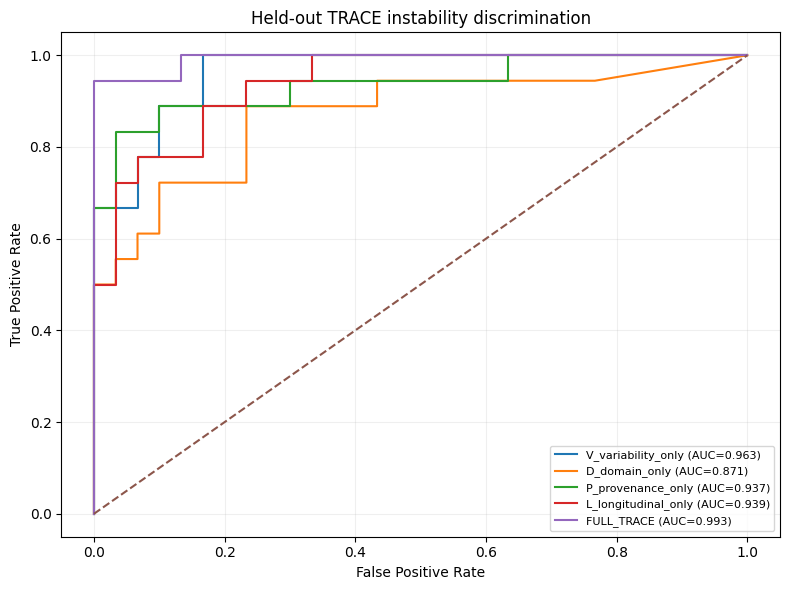

In [18]:

# ============================================================
# 12A. ROC
# ============================================================

fig, ax = plt.subplots(figsize=(8,6))

for name in MODEL_FEATURES:
    p = held_pred[name].values

    if len(np.unique(y_held)) < 2:
        continue

    fpr,tpr,_ = roc_curve(y_held,p)
    auc = roc_auc_score(y_held,p)

    ax.plot(
        fpr,tpr,
        label=f"{name} (AUC={auc:.3f})"
    )

ax.plot([0,1],[0,1],linestyle="--")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Held-out TRACE instability discrimination")
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(
    FIG_DIR/"heldout_trace_roc.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


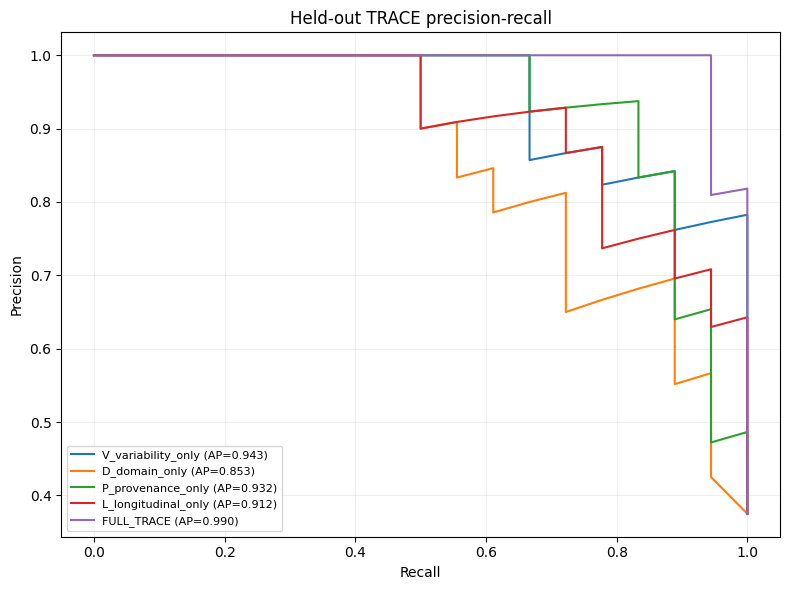

In [19]:

# ============================================================
# 12B. PRECISION-RECALL
# ============================================================

fig, ax = plt.subplots(figsize=(8,6))

for name in MODEL_FEATURES:
    p = held_pred[name].values

    if len(np.unique(y_held)) < 2:
        continue

    precision,recall,_ = precision_recall_curve(
        y_held,p
    )
    ap = average_precision_score(y_held,p)

    ax.plot(
        recall,precision,
        label=f"{name} (AP={ap:.3f})"
    )

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Held-out TRACE precision-recall")
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(
    FIG_DIR/"heldout_trace_pr.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()



# 13. Gate-state distribution


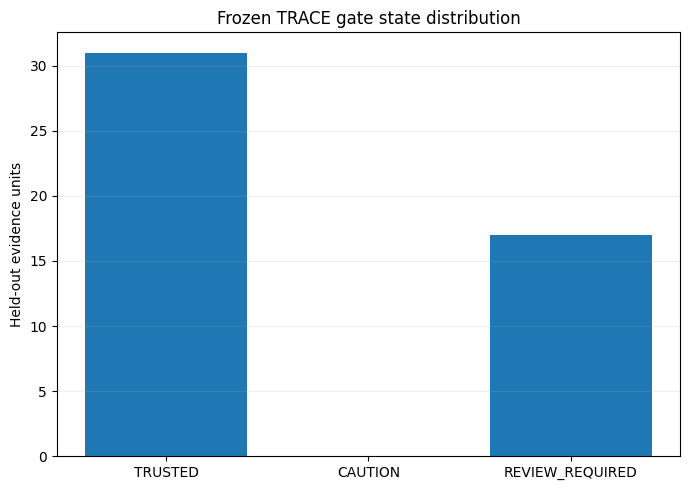

In [20]:

fig, ax = plt.subplots(figsize=(7,5))

state_order = [
    "TRUSTED",
    "CAUTION",
    "REVIEW_REQUIRED"
]

counts = (
    held_pred["trace_state"]
    .value_counts()
    .reindex(state_order)
    .fillna(0)
)

ax.bar(
    counts.index,
    counts.values
)

ax.set_ylabel("Held-out evidence units")
ax.set_title("Frozen TRACE gate state distribution")
ax.grid(axis="y",alpha=0.2)

plt.tight_layout()
plt.savefig(
    FIG_DIR/"heldout_gate_state_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()



# 14. Ablation comparison figure


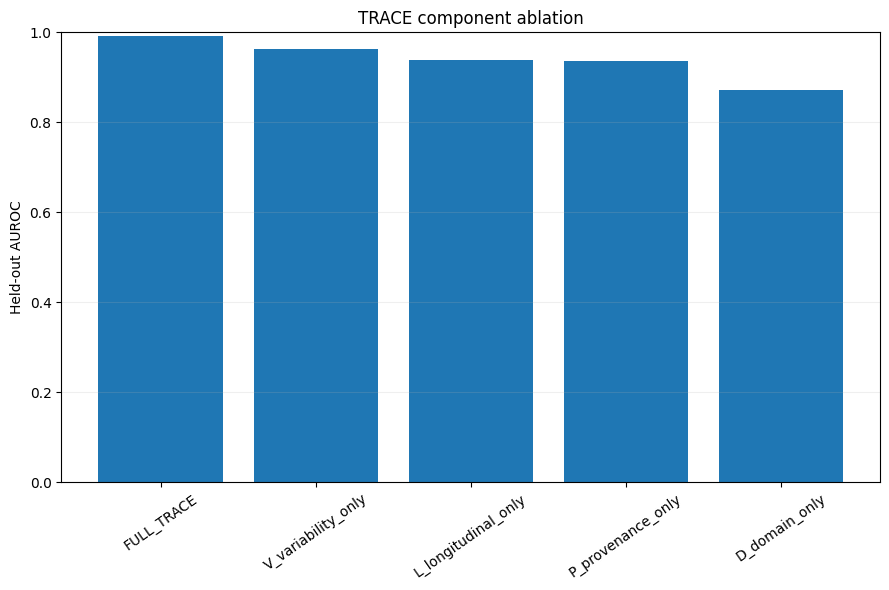

In [21]:

plot_metrics = metrics_df.set_index("model")

fig, ax = plt.subplots(figsize=(9,6))

ax.bar(
    plot_metrics.index,
    plot_metrics["AUROC"]
)

ax.set_ylim(0,1)
ax.set_ylabel("Held-out AUROC")
ax.set_title("TRACE component ablation")
ax.tick_params(axis="x",rotation=35)
ax.grid(axis="y",alpha=0.2)

plt.tight_layout()
plt.savefig(
    FIG_DIR/"trace_ablation_auroc.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()



# 15. Reliability-score distributions


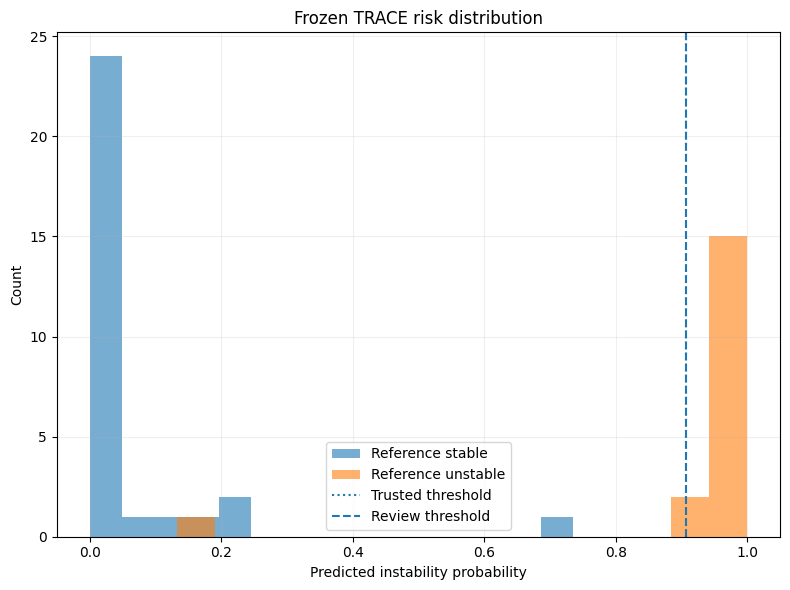

In [22]:

fig, ax = plt.subplots(figsize=(8,6))

stable = held_pred[
    held_pred.unstable_reference==0
]["FULL_TRACE"]

unstable = held_pred[
    held_pred.unstable_reference==1
]["FULL_TRACE"]

ax.hist(
    stable,
    bins=15,
    alpha=0.6,
    label="Reference stable"
)

ax.hist(
    unstable,
    bins=15,
    alpha=0.6,
    label="Reference unstable"
)

ax.axvline(
    trusted_threshold,
    linestyle=":",
    label="Trusted threshold"
)

ax.axvline(
    review_threshold,
    linestyle="--",
    label="Review threshold"
)

ax.set_xlabel("Predicted instability probability")
ax.set_ylabel("Count")
ax.set_title("Frozen TRACE risk distribution")
ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig(
    FIG_DIR/"trace_risk_distributions.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()



# 16. Export final Notebook 20 artifacts

These outputs feed Notebook 21, where TRACE is tested for downstream utility using Models A/B/C.


In [23]:

# ============================================================
# 16. EXPORTS
# ============================================================

held_pred.to_csv(
    OUT_DIR/"heldout_trace_predictions.csv",
    index=False
)

metrics_df.to_csv(
    OUT_DIR/"heldout_ablation_metrics.csv",
    index=False
)

pd.DataFrame([gate_metrics]).to_csv(
    OUT_DIR/"heldout_gate_metrics.csv",
    index=False
)

boot_df.to_parquet(
    OUT_DIR/"subject_bootstrap_results.parquet",
    index=False
)

bootstrap_ci.to_csv(
    OUT_DIR/"subject_bootstrap_ci.csv",
    index=False
)

eval_df.to_parquet(
    OUT_DIR/"trace20_complete_evaluation_table.parquet",
    index=False
)

print("Saved Notebook 20 outputs to:", OUT_DIR)


Saved Notebook 20 outputs to: /content/neurofhir_trace/outputs_20



# 17.  Summary


In [24]:

full_row = metrics_df[
    metrics_df.model=="FULL_TRACE"
].iloc[0]

summary = {
    "DEMO_MODE": bool(DEMO_MODE),
    "N_development_rows": int(len(dev)),
    "N_heldout_rows": int(len(held)),
    "N_heldout_subjects": int(
        held.subject_id.nunique()
    ),
    "Heldout_instability_prevalence": float(
        held.unstable_reference.mean()
    ),
    "Frozen_TRUSTED_threshold": float(
        trusted_threshold
    ),
    "Frozen_REVIEW_threshold": float(
        review_threshold
    ),
    "FULL_TRACE_AUROC": float(
        full_row.AUROC
    ),
    "FULL_TRACE_AUPRC": float(
        full_row.AUPRC
    ),
    "FULL_TRACE_Brier": float(
        full_row.Brier
    ),
    "FULL_TRACE_ECE": float(
        full_row.ECE_10bin
    ),
    **gate_metrics
}

summary_df = pd.DataFrame(
    list(summary.items()),
    columns=["metric","value"]
)

display(summary_df)

summary_df.to_csv(
    OUT_DIR/"ichi_trace_20_summary.csv",
    index=False
)


,metric,value
0,DEMO_MODE,True
1,N_development_rows,112
2,N_heldout_rows,48
3,N_heldout_subjects,48
4,Heldout_instability_prevalence,0.375
5,Frozen_TRUSTED_threshold,0.906566
6,Frozen_REVIEW_threshold,0.906567
7,FULL_TRACE_AUROC,0.992593
8,FULL_TRACE_AUPRC,0.989899
9,FULL_TRACE_Brier,0.03008



# 18. Decision gate for proceeding to Notebook 21

## PASS to downstream A/B/C experiment when:

1. the held-out evaluation uses a reference not directly defined by the same TRACE score;
2. the subject split was frozen before evaluation;
3. full TRACE shows useful discrimination or meaningful capture of unstable evidence;
4. review routing is not so extreme that nearly all evidence is rejected;
5. at least one reliability outcome is improved or informative even if AUROC is not spectacular;
6. the final manuscript clearly distinguishes technical reliability from clinical validity.

### Strong result
Full TRACE materially outperforms individual components and captures a large fraction of false/unstable evidence at a manageable review rate.

### Acceptable result
Full TRACE is similar to the best single component but provides better calibration, more interpretable routing, or better false-change control.

### Weak result
Performance is driven entirely by one trivially circular signal or requires routing almost everything to review.

---

# Next notebook — 21

## Downstream Model A vs B vs C

The next notebook will test the principal ICHI utility claim:

### Model A — Clinical baseline
Clinical/non-imaging predictors only.

### Model B — Raw imaging AI
Clinical predictors + all AI-derived imaging evidence without TRACE.

### Model C1 — Trusted-only
Clinical predictors + imaging evidence only when TRACE says TRUSTED.

### Model C2 — Reliability-weighted
Clinical predictors + imaging features attenuated by TRACE reliability.

### Model C3 — Full TRACE gate
Clinical predictors + reliability state, reasons, longitudinal plausibility, provenance, and gated imaging evidence.

Primary comparison:

> Does controlling patient-level imaging evidence quality improve calibration, false-change control, ranking stability, or robustness under shift relative to blindly propagating raw AI-derived imaging features?

A higher AUROC is welcome but **not required** for a successful TRACE paper.
